In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set display options for better readability
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

In [30]:
import warnings
warnings.filterwarnings('ignore')
from 

SyntaxError: invalid syntax (2075796979.py, line 3)

In [ ]:
file_path = '/home/divas/ml/logistics_project/data/raw/used_cars.csv'
df = pd.read_csv(file_path)

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4009 entries, 0 to 4008
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   brand         4009 non-null   str  
 1   model         4009 non-null   str  
 2   model_year    4009 non-null   int64
 3   milage        4009 non-null   str  
 4   fuel_type     3839 non-null   str  
 5   engine        4009 non-null   str  
 6   transmission  4009 non-null   str  
 7   ext_col       4009 non-null   str  
 8   int_col       4009 non-null   str  
 9   accident      3896 non-null   str  
 10  clean_title   3413 non-null   str  
 11  price         4009 non-null   str  
dtypes: int64(1), str(11)
memory usage: 376.0 KB


## Data Preprocessing



In [ ]:
import sys
import os

# This tells Python to look one folder up (the project root)
sys.path.append(os.path.abspath(os.path.join('..')))

In [ ]:
from src.data_cleaning import DataCleaner
cleaner = DataCleaner()
cleaned_df = cleaner.transform(df)

In [ ]:
df = cleaned_df.copy()
df.head()

,brand,model,model_year,fuel_type,engine,transmission,ext_col,int_col,accident,price_usd,mileage_num,has_clean_title
0,Ford,Utility Police Interceptor Base,2013,E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,10300,51000,1
1,Hyundai,Palisade SEL,2021,Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,38005,34742,1
2,Lexus,RX 350 RX 350,2022,Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,54598,22372,0
3,INFINITI,Q50 Hybrid Sport,2015,Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,15500,88900,1
4,Audi,Q3 45 S line Premium Plus,2021,Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,34999,9835,0


In [ ]:
df.describe()

,model_year,price_usd,mileage_num,has_clean_title
count,4009.000000,4.009000e+03,4009.000000,4009.000000
mean,2015.515590,4.455319e+04,64717.551010,0.851334
std,6.104816,7.871064e+04,52296.599459,0.355803
min,1974.000000,2.000000e+03,100.000000,0.000000
25%,2012.000000,1.720000e+04,23044.000000,1.000000
50%,2017.000000,3.100000e+04,52775.000000,1.000000
75%,2020.000000,4.999000e+04,94100.000000,1.000000
max,2024.000000,2.954083e+06,405000.000000,1.000000


#### Analyzing Missing values

In [ ]:
# Count missing values per column
missing_count = df.isnull().sum()

# Percentage of missing values per column
missing_percent = (df.isnull().sum() / len(df)) * 100
missing_percent[missing_percent > 0]

fuel_type    5.412821
accident     2.818658
dtype: float64

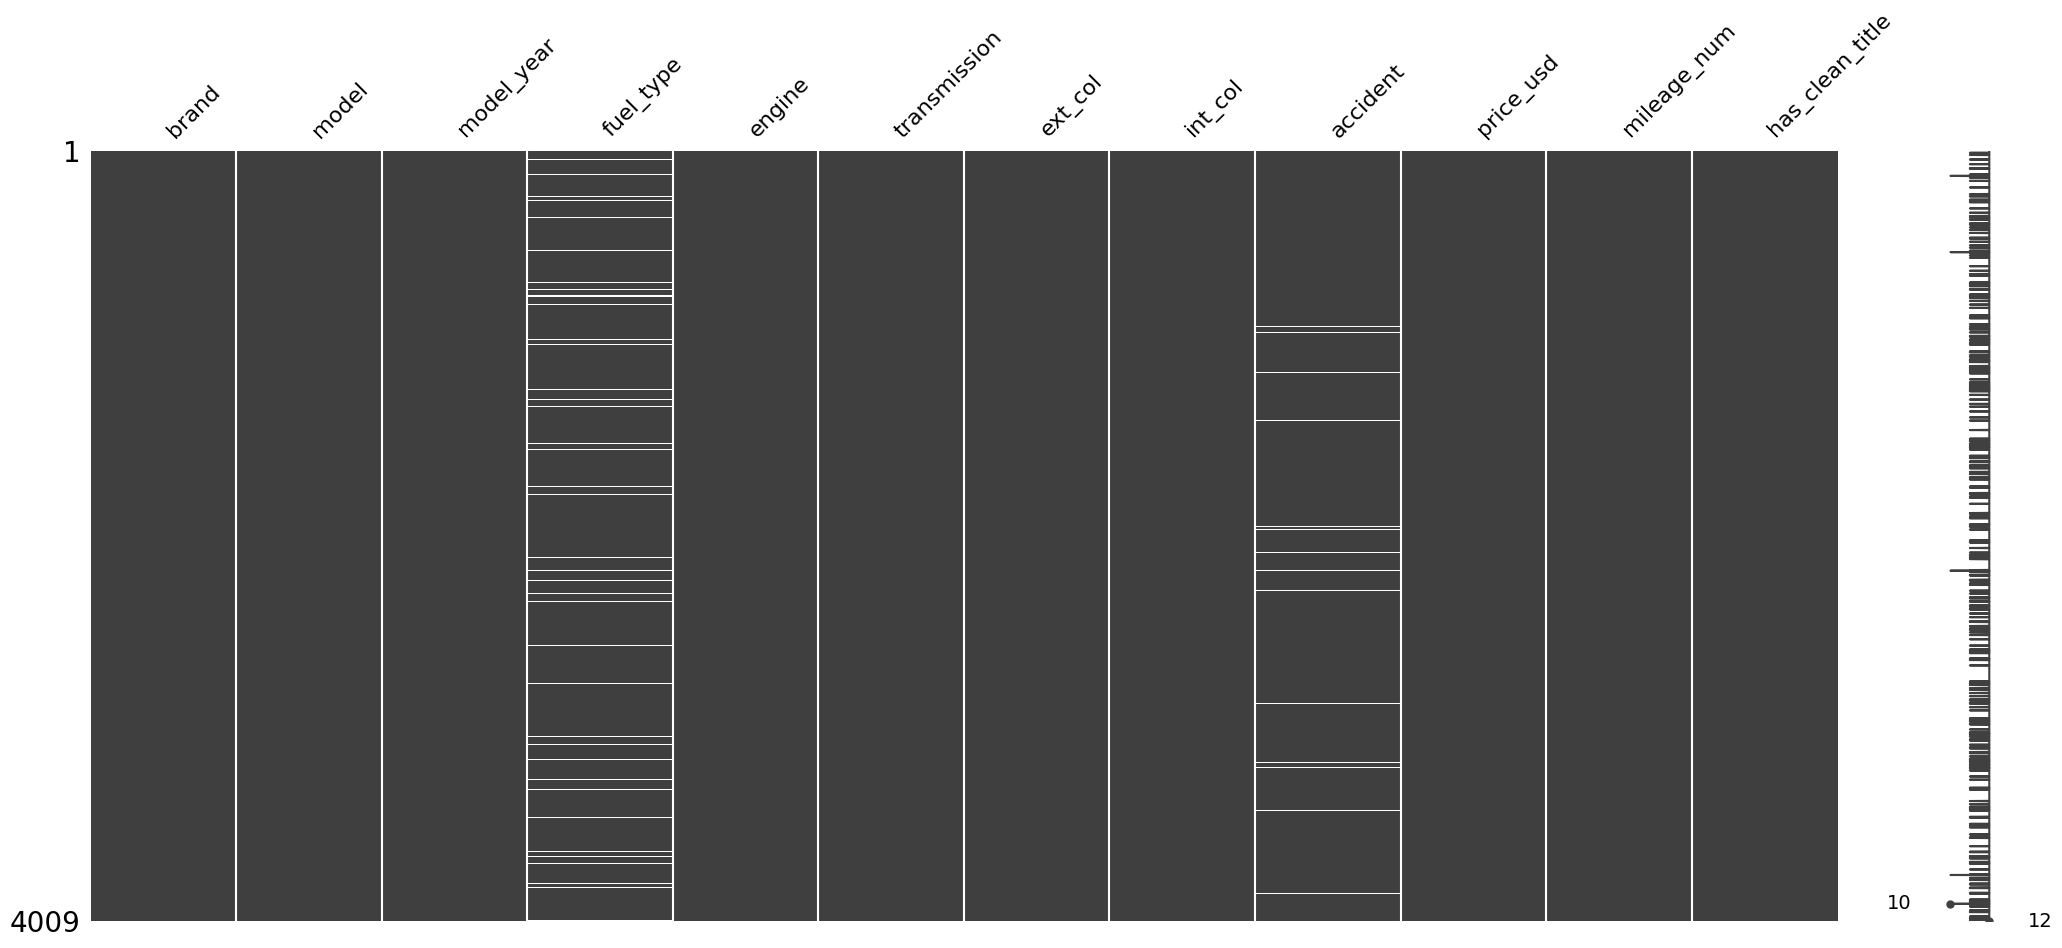

In [ ]:
import missingno as msno
import matplotlib.pyplot as plt

# Visualizes the dataset as a matrix where white lines represent missing values
msno.matrix(df)
plt.show()

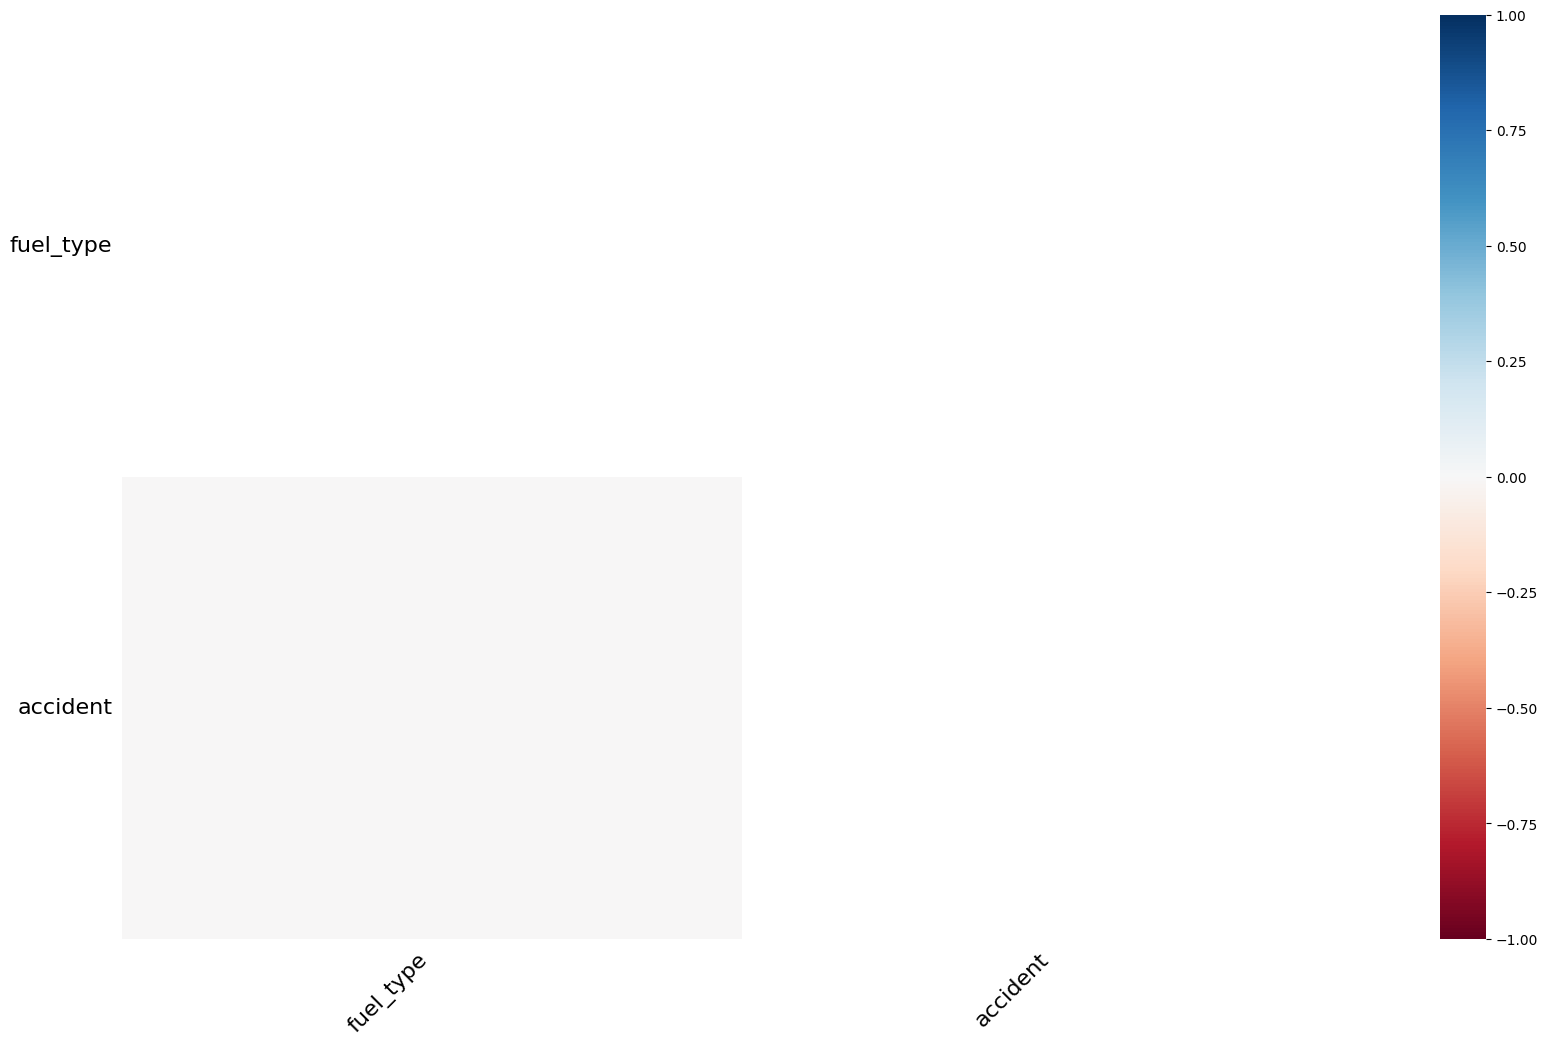

In [ ]:
msno.heatmap(df)
plt.show()

## Univariate analysis


### Analyze numeric variables

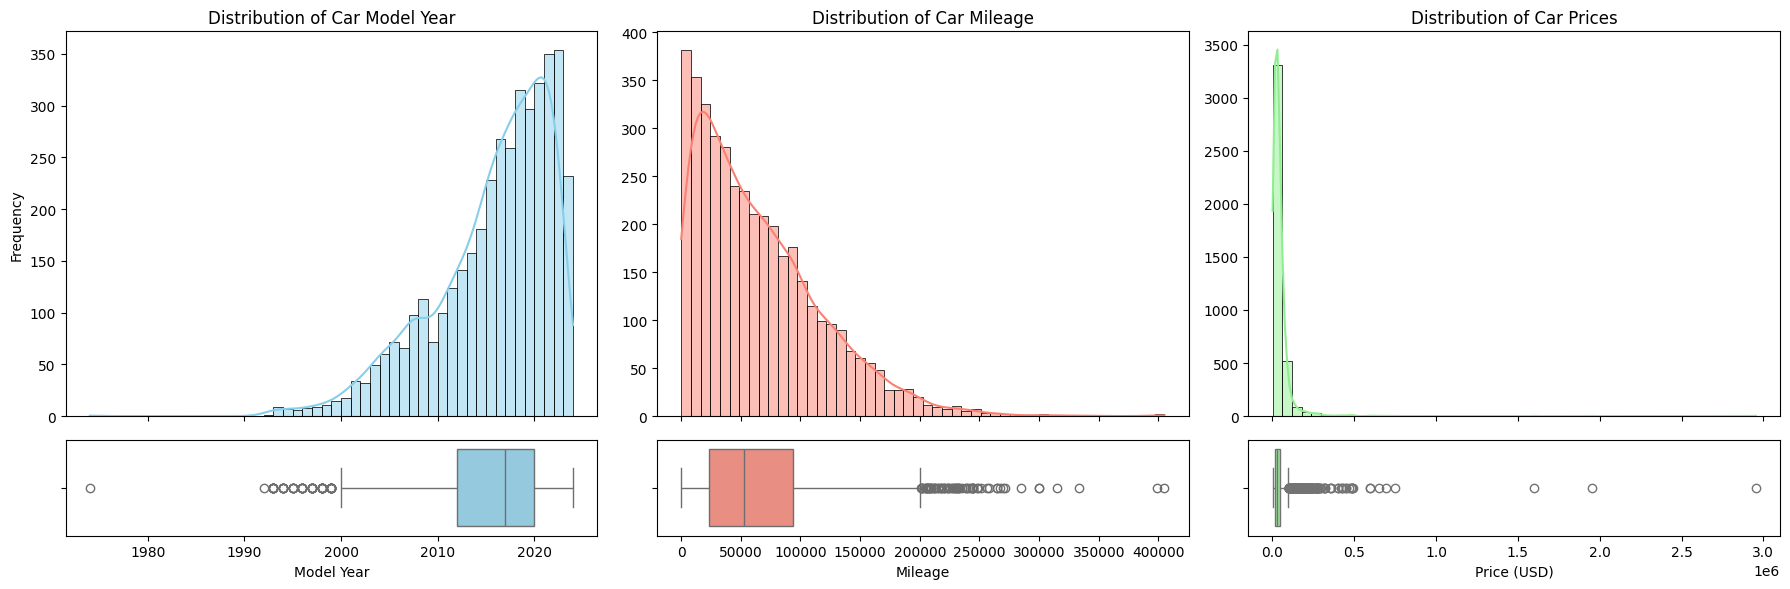

In [ ]:

# height_ratios keeps the boxplots skinny at the bottom
fig, axs = plt.subplots(
    nrows=2, ncols=3, figsize=(18, 6), sharex=False,
    gridspec_kw={"height_ratios": (0.8, 0.2)}
)

# Unpack the axes array for easy referencing
# Row 0 handles histograms, Row 1 handles boxplots
(ax1_hist, ax2_hist, ax3_hist) = axs[0]
(ax1_box, ax2_box, ax3_box) = axs[1]

# ------------------------------------------------------------------
# COLUMN 1: Model Year
# ------------------------------------------------------------------
sns.histplot(data=cleaned_df, x='model_year', bins=50, kde=True, ax=ax1_hist, color='skyblue')
ax1_hist.set_title('Distribution of Car Model Year')
ax1_hist.set_ylabel('Frequency')
ax1_hist.set_xlabel('')
ax1_hist.set_xticklabels([]) # Hide labels to prevent overlap with the boxplot

sns.boxplot(data=cleaned_df, x='model_year', ax=ax1_box, color='skyblue')
ax1_box.set_xlabel('Model Year')

# ------------------------------------------------------------------
# COLUMN 2: Mileage
# ------------------------------------------------------------------
sns.histplot(data=cleaned_df, x='mileage_num', bins=50, kde=True, ax=ax2_hist, color='salmon')
ax2_hist.set_title('Distribution of Car Mileage')
ax2_hist.set_ylabel('') # Clear Y-label for cleaner side-by-side look
ax2_hist.set_xlabel('')
ax2_hist.set_xticklabels([])

sns.boxplot(data=cleaned_df, x='mileage_num', ax=ax2_box, color='salmon')
ax2_box.set_xlabel('Mileage')

# ------------------------------------------------------------------
# COLUMN 3: Price
# ------------------------------------------------------------------
sns.histplot(data=cleaned_df, x='price_usd', bins=50, kde=True, ax=ax3_hist, color='lightgreen')
ax3_hist.set_title('Distribution of Car Prices')
ax3_hist.set_ylabel('')
ax3_hist.set_xlabel('')
ax3_hist.set_xticklabels([])

sns.boxplot(data=cleaned_df, x='price_usd', ax=ax3_box, color='lightgreen')
ax3_box.set_xlabel('Price (USD)')

# ------------------------------------------------------------------
# 4. Final adjustments and display
# ------------------------------------------------------------------
plt.tight_layout()
plt.show()

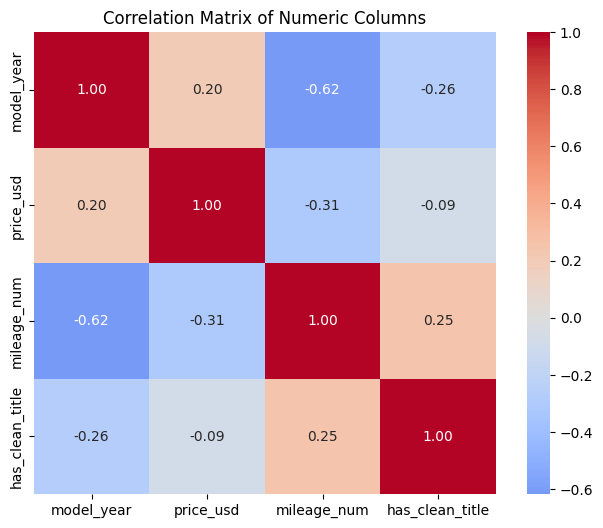

In [ ]:
numeric_cols = df.select_dtypes(include=np.number).columns
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Correlation Matrix of Numeric Columns')
plt.show()

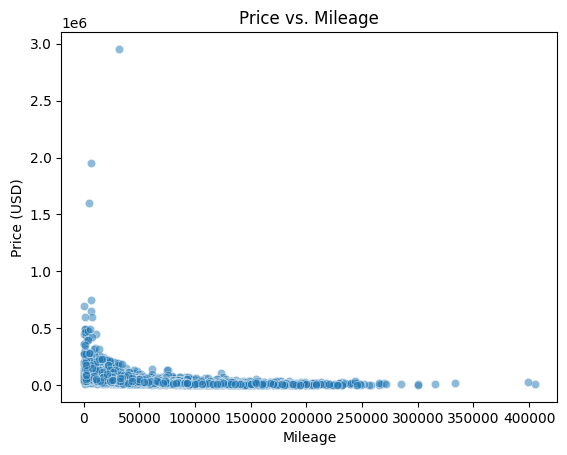

In [ ]:
sns.scatterplot(data=df, x='mileage_num', y='price_usd', alpha=0.5)
plt.title('Price vs. Mileage')
plt.xlabel('Mileage')
plt.ylabel('Price (USD)')
plt.show()

### Analyze categorical variables

In [ ]:
cat_cols= df.select_dtypes(include='object').columns
for col in cat_cols:
    print(f"Nunique {col}: {df[col].nunique()}")

Nunique brand: 57
Nunique model: 1898
Nunique fuel_type: 5
Nunique engine: 1146
Nunique transmission: 62
Nunique ext_col: 319
Nunique int_col: 156
Nunique accident: 2


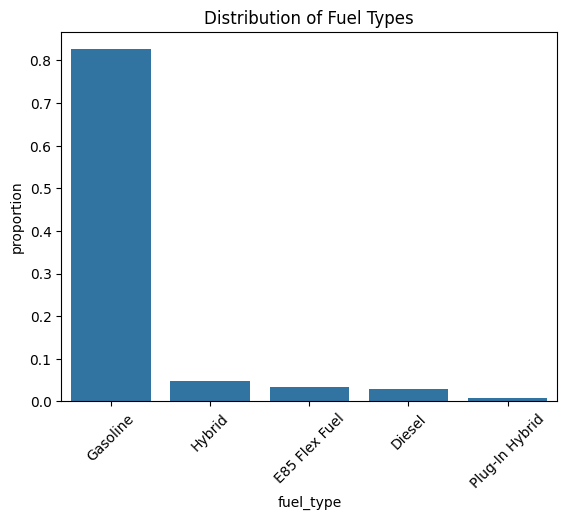

In [ ]:
# Count plot for fuel type
sns.countplot(data=df, x='fuel_type', order=df['fuel_type'].value_counts().index, stat='proportion')
plt.title('Distribution of Fuel Types')
plt.xticks(rotation=45)
plt.show()

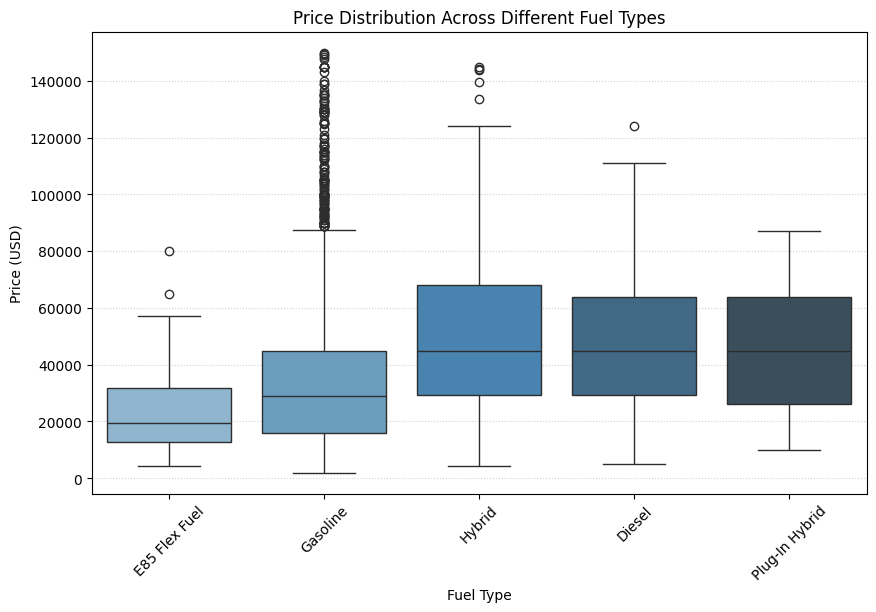

In [ ]:
# (Adjust the 150000 threshold based on your zoomed data)
filtered_df = df[df['price_usd'] < 150000]

plt.figure(figsize=(10, 6))
sns.boxplot(data=filtered_df, x='fuel_type', y='price_usd', palette='Blues_d')
plt.title('Price Distribution Across Different Fuel Types')
plt.xticks(rotation=45)
plt.xlabel('Fuel Type')
plt.ylabel('Price (USD)')
plt.grid(axis='y', linestyle=':', alpha=0.6)
plt.show()

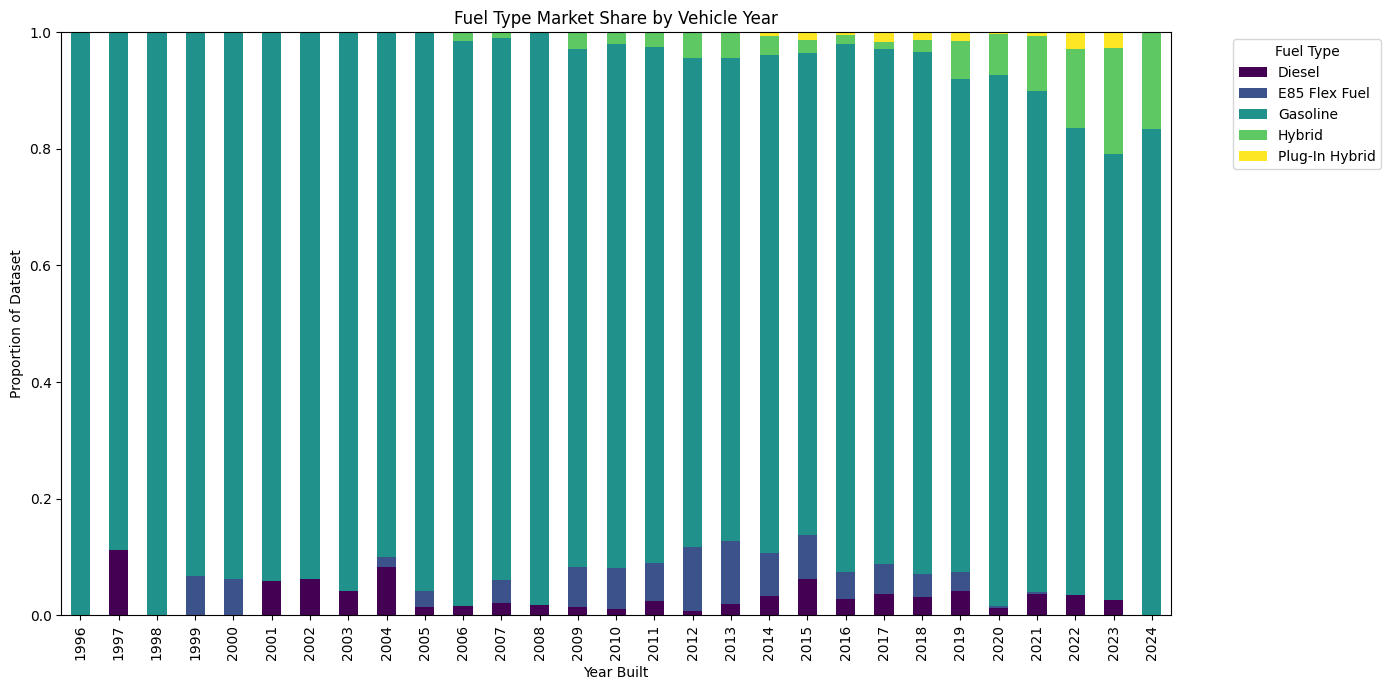

In [ ]:
# 1. Calculate the percentage distribution of fuel types for each year
year_fuel_pct = (
    df.groupby("model_year")["fuel_type"]
    .value_counts(normalize=True)
    .unstack()
    .fillna(0)
)

# 2. Plot a stacked bar chart over time
year_fuel_pct.plot(kind="bar", stacked=True, figsize=(14, 7), colormap="viridis")

plt.title("Fuel Type Market Share by Vehicle Year")
plt.xlabel("Year Built")
plt.ylabel("Proportion of Dataset")
plt.legend(title="Fuel Type", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [ ]:
from scipy import stats

# 1. Group years by each fuel type category
groups = [group["model_year"].values for name, group in df.groupby("fuel_type")]

# 2. Run the Kruskal-Wallis test
stat, p_value = stats.kruskal(*groups)

print(f"Kruskal-Wallis H-statistic: {stat:.4f}")
print(f"p-value: {p_value:.4e}")

if p_value < 0.05:
    print("Verdict: SIGNIFICANT DEPENDENCY. The age distribution varies drastically by fuel type.")
else:
    print("Verdict: NO SIGNIFICANT DEPENDENCY. The age distribution is similar across fuel types.")

Kruskal-Wallis H-statistic: 179.3254
p-value: 1.0409e-37
Verdict: SIGNIFICANT DEPENDENCY. The age distribution varies drastically by fuel type.


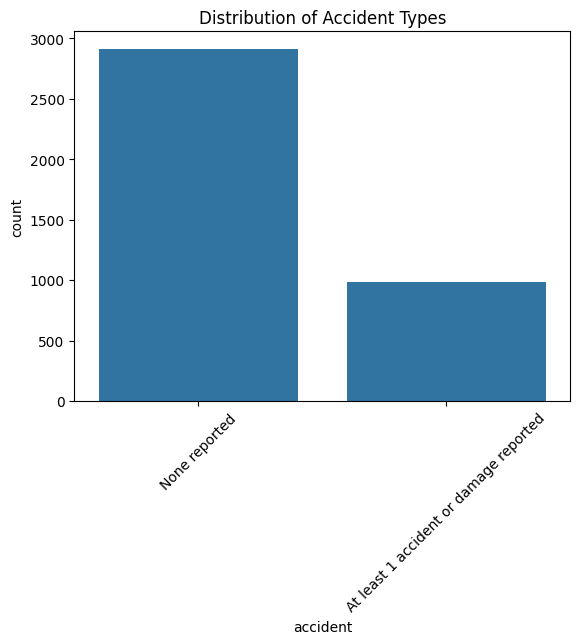

In [ ]:
# Count plot for accident  type
sns.countplot(data=df, x='accident', order=df['accident'].value_counts().index)
plt.title('Distribution of Accident Types')
plt.xticks(rotation=45)
plt.show()

#### Analyzig mid cardinality variables

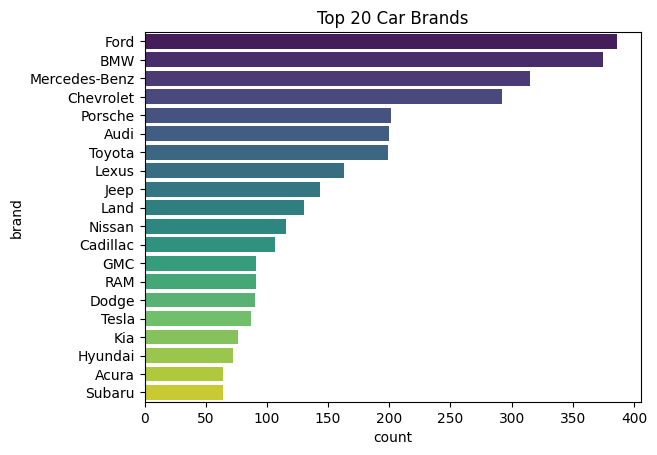

In [ ]:
# Get the top 20 most frequent brands
top_brands = df['brand'].value_counts().nlargest(20).index

# Plot only those top 20 horizontally so the labels are readable
sns.countplot(data=df[df['brand'].isin(top_brands)], y='brand', 
              order=top_brands, palette='viridis')
plt.title('Top 20 Car Brands')
plt.show()

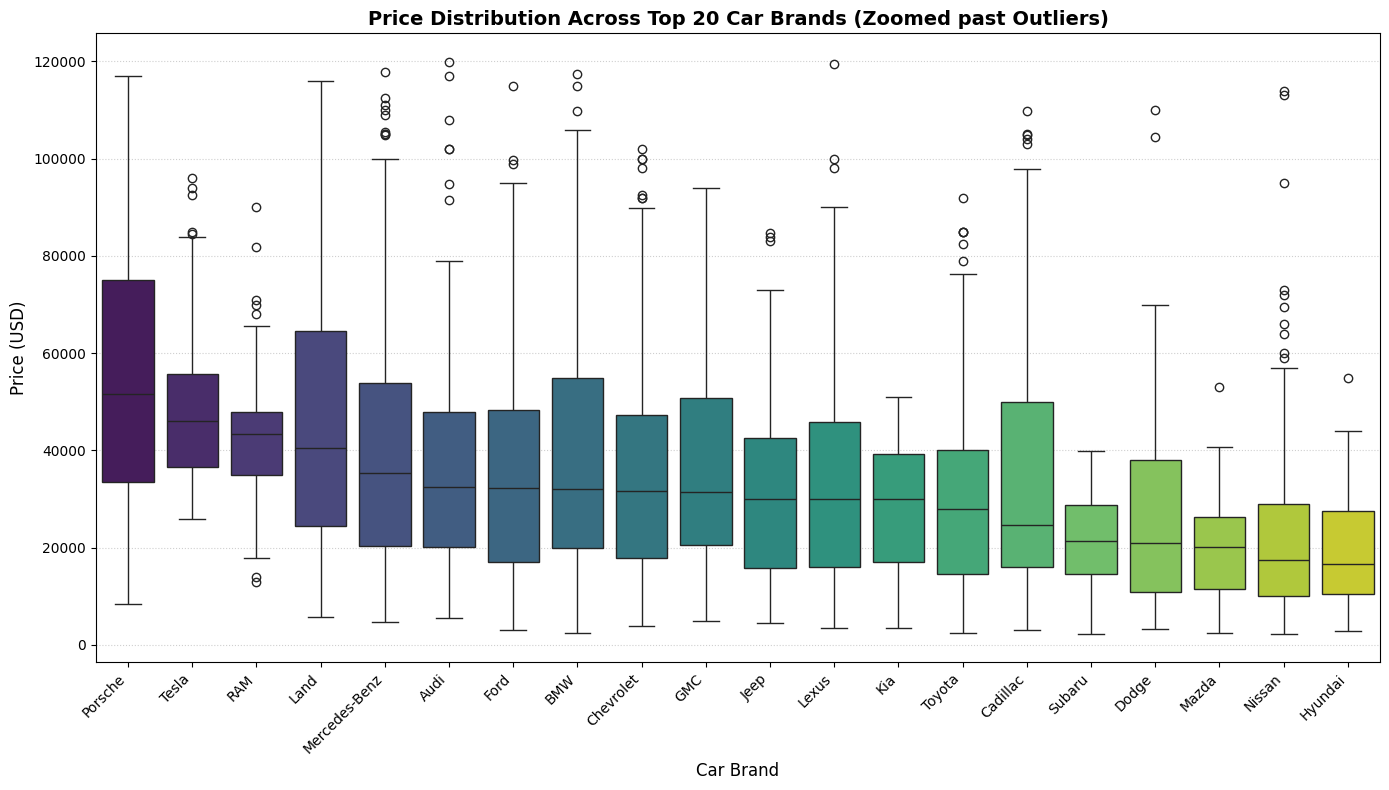

In [ ]:

zoom_df = df[df['price_usd'] < 120000]
brand_order = zoom_df['brand'].value_counts().index[:20]
filtered_top_20 = zoom_df[zoom_df['brand'].isin(brand_order)]

brand_order = (
    filtered_top_20.groupby("brand")["price_usd"]
    .median()
    .sort_values(ascending=False)
    .index
)

plt.figure(figsize=(14, 8))
sns.boxplot(
    data=filtered_top_20, 
    x='brand', 
    y='price_usd', 
    order=brand_order, 
    palette='viridis' # Matches the beautiful gradient from your bar chart
)

# 5. Styling and labels
plt.title('Price Distribution Across Top 20 Car Brands (Zoomed past Outliers)', fontsize=14, fontweight='bold')
plt.xlabel('Car Brand', fontsize=12)
plt.ylabel('Price (USD)', fontsize=12)
plt.xticks(rotation=45, ha='right') # Tilts labels so they don't overlap
plt.grid(axis='y', linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

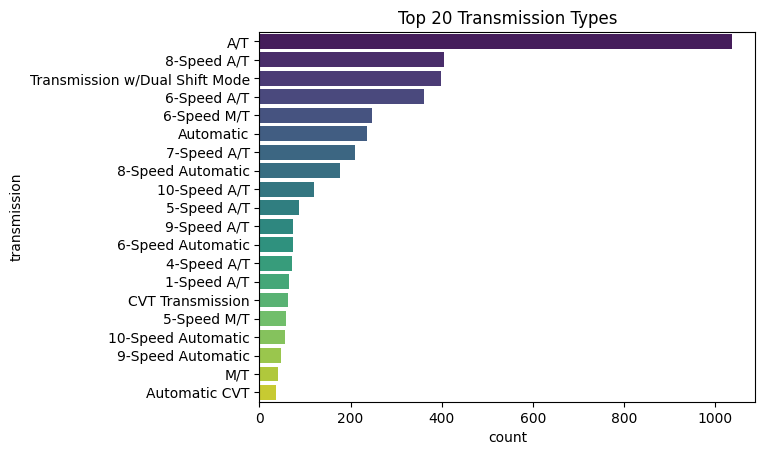

In [ ]:
# Get the top 20 most frequent brands
top_brands = df['transmission'].value_counts().nlargest(20).index

# Plot only those top 20 horizontally so the labels are readable
sns.countplot(data=df[df['transmission'].isin(top_brands)], y='transmission', 
              order=top_brands, palette='viridis')
plt.title('Top 20 Transmission Types')
plt.show()

N-gears can we extracted, 
And categories can be mapped to automatic, cvt, or manual

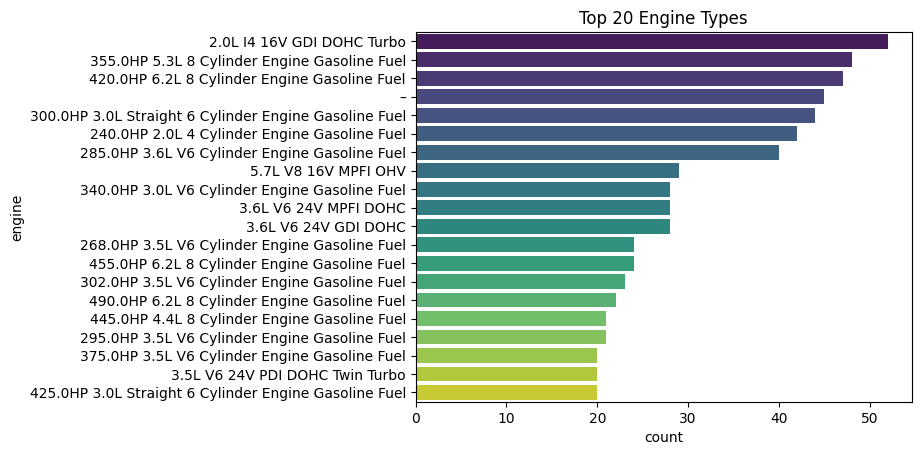

In [ ]:
# Get the top 20 most frequent brands
top_brands = df['engine'].value_counts().nlargest(20).index

# Plot only those top 20 horizontally so the labels are readable
sns.countplot(data=df[df['engine'].isin(top_brands)], y='engine', 
              order=top_brands, palette='viridis')
plt.title('Top 20 Engine Types')
plt.show()

Some features can be extracted from engine types

#### Analyzing high cardinality variables

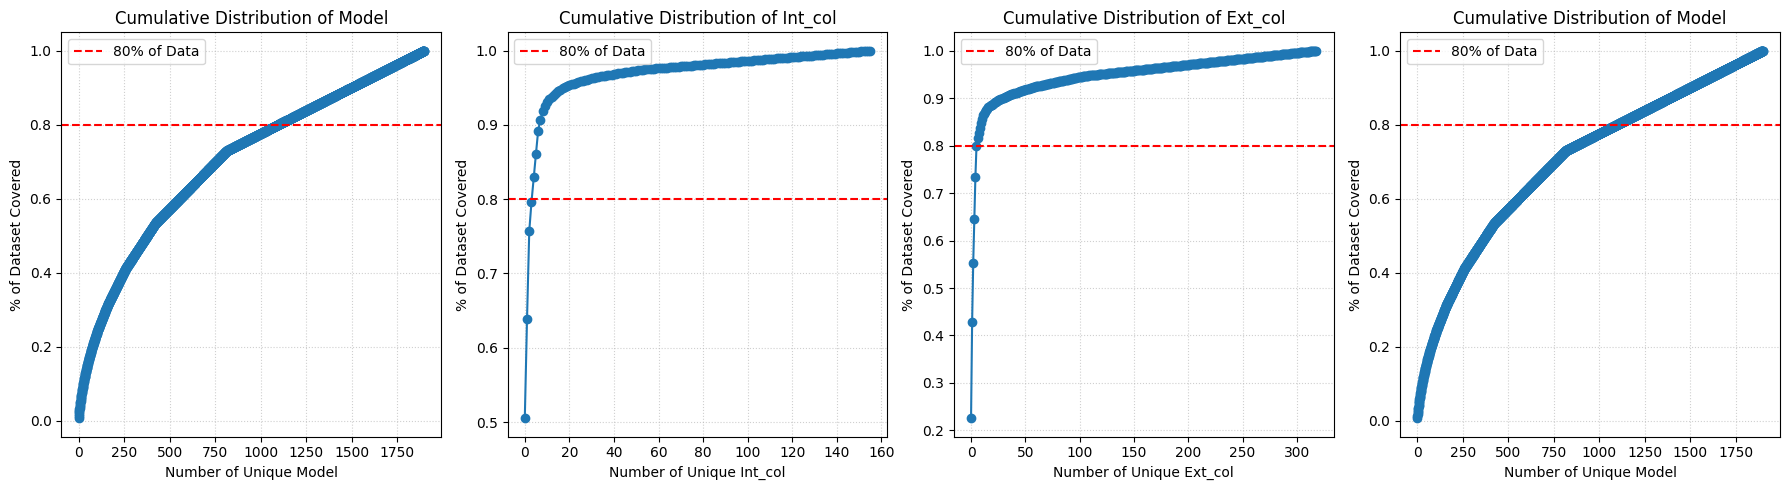

In [ ]:
# 1. Define the features you want to analyze
features = ['model', 'int_col', 'ext_col', 'model']

# 2. Create a subplot grid (1 row, 3 columns)
# figsize sets the width and height of the entire window
fig, axes = plt.subplots(nrows=1, ncols=4, figsize=(18, 5))

# 3. Loop through your features and their corresponding plotting boxes (axes)
for i, feature in enumerate(features):
    # Select the current subplot axis
    ax = axes[i]
    
    # Calculate cumulative percentage for the current feature
    counts = df[feature].value_counts(normalize=True).cumsum()
    
    # Plot the curve on this specific subplot axis ('ax=ax' or calling ax.plot)
    ax.plot(range(len(counts)), counts.values, marker='o', linestyle='-')
    
    # Add the 80% reference line to this specific subplot
    ax.axhline(y=0.8, color='r', linestyle='--', label='80% of Data')
    
    # Customize titles and labels for this specific subplot
    ax.set_title(f'Cumulative Distribution of {feature.capitalize()}')
    ax.set_xlabel(f'Number of Unique {feature.capitalize()}')
    ax.set_ylabel('% of Dataset Covered')
    ax.legend()
    ax.grid(True, linestyle=':', alpha=0.6) # Optional: adds a subtle background grid

# 4. Adjust layout automatically so titles/labels don't overlap
plt.tight_layout()
plt.show()

### Feature Engineering


In [ ]:
# Extract premium trims, sport packages, or body types
df['is_sport'] = df['model'].str.contains('Sport|S-Line|M Sport', case=False).astype(int)
df['is_premium'] = df['model'].str.contains('Premium|Platinum|Limited', case=False).astype(int)
df['is_4WD_AWD'] = df['model'].str.contains('4WD|xDrive|Quattro|AWD', case=False).astype(int)
df.drop(['model'], axis=1, inplace=True)

In [ ]:
def clean_and_map_interior_colors_vectorized(df: pd.DataFrame) -> pd.DataFrame:
    for col in ['int_col', 'ext_col']:
        df = df.copy()

        # Step 1: Vectorized String Normalization
        # Lowercase, strip whitespace, and eliminate junk characters across the entire Series
        clean_series = (
            df[col]
            .astype(str)
            .str.lower()
            .str.strip()
            .str.replace(r"[.\-]", "", regex=True)
        )

        # Step 2: Vectorized Handling of Corrupted Token (ΓÇô), Empty Strings, or Literal NaNs
        # This turns them into a single string 'unknown' to make regex matching safe
        junk_mask = clean_series.isin(["γçô", "nan", "other", ""]) | clean_series.isna()
        clean_series = np.where(junk_mask, "unknown", clean_series)
        clean_series = pd.Series(clean_series)

        # Step 3: Define Categorization Rules using Vectorized Regex Patterns
        # '|'.join() creates an "OR" regex matching configuration (e.g., 'black|blk|ebony')
        conditions = [
            clean_series.str.contains(r"black|blk|ebony|nero|charcoal|obsidian|beluga|amg|graphite|carbon"),
            clean_series.str.contains(r"beige|tan|parchment|sandstone|canberra|shara|macchiato|almond|shale|cashmere|linen|ivory|silk"),
            clean_series.str.contains(r"gray|grey|slate|pewter|titan|boulder|ash|platinum|silver|galvanized|gideon"),
            clean_series.str.contains(r"brown|walnut|espresso|caramel|cappuccino|nougat|sarder|mesa|tupelo|mocha|saddle|auburn|amber|brandy|mountain|aragon|chestnut|cocoa|dune|roast"),
            clean_series.str.contains(r"red|hotspur|rioja|pimento|magma|garnet|chateau|adrenaline"),
            clean_series.str.contains(r"blue|navy|cobalt|rhapsody|charles|mistral|porpoise"),
            clean_series.str.contains(r"orange|sakhir|kyalami|giallo|taurus|yellow"),
            clean_series.str.contains(r"white|ice|pearl|grace|cloud|whisper|bianco|polar"),
            clean_series == "unknown"
        ]

        # Matching outputs for each condition group above
        choices = [
            "Black", 
            "Beige", 
            "Gray", 
            "Brown", 
            "Red", 
            "Blue", 
            "Orange", 
            "White", 
            "Unknown"
        ]

        # Step 4: Execute np.select Vectorized Mapping Engine
        # Any value that fails to match the rules above defaults to "Other"
        df[col] = np.select(conditions, choices, default="Other")
    return df

In [ ]:
df = clean_and_map_interior_colors_vectorized(df)

In [ ]:
mode_accident = df['accident'].mode()
accident_map = {
    'no accidents': 0,
    'At least 1 accident or damage reported': 1}
df['accident'] = df['accident'].map(accident_map)
df['accident'] = df['accident'].fillna(0)

In [ ]:
def clean_and_feature_engineer_transmission(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # Step 1: Broad Normalization (Lowercase and clean whitespace)
    raw_series = df["transmission"].astype(str).str.lower().str.strip()

    # Create masks for clean handling of obvious noise tokens
    junk_strings = ["γçô", "scheduled for or in production", "nan", ""]
    raw_series = np.where(raw_series.isin(junk_strings), "unknown", raw_series)
    raw_series = pd.Series(raw_series)  # Ensure it's a Series for regex operations
    # ------------------------------------------------------------------ #
    # Feature 1: Vectorized Transmission Type Extraction                 #
    # ------------------------------------------------------------------ #
    # Define boolean arrays based on keyword hierarchies

    is_cvt = raw_series.str.contains(r"cvt|variable")
    is_manual = raw_series.str.contains(r"m/t|manual|mt")
    
    # "Automatic" checks for explicit auto terms OR general shorthand like 'a/t' or 'at'
    is_auto = raw_series.str.contains(r"a/t|automatic|auto|at|pdk|dct|steptronic|tronic|shift")

    # Combine conditions using NumPy select (Order matters: CVT checked first)
    type_conditions = [is_cvt, is_manual, is_auto, raw_series == "unknown"]
    type_choices = ["CVT", "Manual", "Automatic", "Unknown"]
    
    df["transmission_type"] = np.select(type_conditions, type_choices, default="Automatic")

    # ------------------------------------------------------------------ #
    # Feature 2: Vectorized Gear/Speed Count Extraction                   #
    # ------------------------------------------------------------------ #
    # Use regular expressions to extract any numbers sitting right next to "speed", "spd", or "speed"
    # Example: "8-speed a/t" -> "8", "automatic, 9-spd" -> "9"
    raw_series = pd.Series(raw_series)  # Ensure it's a Series for regex operations

    extracted_gears = raw_series.str.extract(r"(\d+)\s*(?:-speed|spd|speed|gear)")
    
    # Fallback regex check: just look for standalone numbers if the speed suffix wasn't used
    fallback_gears = raw_series.str.extract(r"\b(\d+)\b")
    
    # Fill missing values from the first regex pass with matches from the fallback pass
    final_gears = extracted_gears[0].fillna(fallback_gears[0])
    
    # Convert to numeric float so it can handle missing values cleanly as NaNs
    df["transmission_gears"] = pd.to_numeric(final_gears, errors="coerce")

    # Business rule correction: If it's a CVT, it shouldn't have discrete gears.
    # We set CVT gear counts to 0 or leave as NaN based on model preference.
    df.loc[df["transmission_type"] == "CVT", "transmission_gears"] = 0
    
    # Fill remaining completely unidentifiable gear numbers (like string "f" or "automatic") with median
    # (Do this processing step within your pipeline imputer setup later if preferred)
    df.drop(['transmission'], axis=1, inplace=True)
    return df

In [ ]:
df = clean_and_feature_engineer_transmission(df)
df.head()

,brand,model_year,fuel_type,engine,ext_col,int_col,accident,price_usd,mileage_num,has_clean_title,is_sport,is_premium,is_4WD_AWD,transmission_type,transmission_gears
0,Ford,2013,E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,Black,Black,1.0,10300,51000,1,0,0,0,Automatic,6.0
1,Hyundai,2021,Gasoline,3.8L V6 24V GDI DOHC,White,Gray,1.0,38005,34742,1,0,0,0,Automatic,8.0
2,Lexus,2022,Gasoline,3.5 Liter DOHC,Blue,Black,0.0,54598,22372,0,0,0,0,Automatic,NaN
3,INFINITI,2015,Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,Black,Black,0.0,15500,88900,1,1,0,0,Automatic,7.0
4,Audi,2021,Gasoline,2.0L I4 16V GDI DOHC Turbo,White,Black,0.0,34999,9835,0,0,1,0,Automatic,8.0


In [ ]:
import re
def process_engine_specs_vectorized(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # Step 1: Base Normalization and Encoding Cleanup
    raw_series = df["engine"].astype(str).str.strip()

    # Detect corrupted placeholder strings and fill with a safe indicator
    junk_mask = raw_series.isin(["ΓÇô", "nan", ""]) | raw_series.isna()
    raw_series = np.where(junk_mask, "unknown", raw_series)
    raw_series = pd.Series(raw_series)  # Ensure it's a Series for regex operations

    # ------------------------------------------------------------------
    # Feature 1: Vectorized Horsepower (HP) Extraction
    # ------------------------------------------------------------------
    # Extract any numeric sequences preceding 'HP' or 'hp'
    df["engine_hp"] = pd.to_numeric(
        raw_series.str.extract(r"(\d+(?:\.\d+)?)\s*HP", flags=re.IGNORECASE)[0],
        errors="coerce",
    )

    # ------------------------------------------------------------------
    # Feature 2: Vectorized Displacement (Liters) Extraction
    # ------------------------------------------------------------------
    # Target formats: "2.0L", "3.0 Liter", "4L"
    disp_extracted = raw_series.str.extract(
        r"(\d+(?:\.\d+)?)\s*(?:L|Liter)", flags=re.IGNORECASE
    )[0]
    df["engine_displacement"] = pd.to_numeric(disp_extracted, errors="coerce")

    # ------------------------------------------------------------------
    # Feature 3: Vectorized Cylinder Count Extraction
    # ------------------------------------------------------------------
    # Look for explicitly stated names: "8 Cylinder", "10 Cylinder"
    cyl_word_match = raw_series.str.extract(
        r"(\d+)\s*Cylinder", flags=re.IGNORECASE
    )[0]

    # Look for structural layout shorthand expressions: "V6", "I4", "H6", "V-10"
    cyl_short_match = raw_series.str.extract(
        r"\b(?:V|I|H|V-)(\d+)\b", flags=re.IGNORECASE
    )[0]

    # Look for specialized text expressions: "Straight 6", "Flat 6"
    cyl_text_match = np.where(
        raw_series.str.contains(r"Straight 6|Flat 6", flags=re.IGNORECASE),
        "6",
        None,
    )

    # Coalesce the extractions prioritising explicit words, then shorthand, then custom text
    final_cylinders = (
        cyl_word_match.fillna(cyl_short_match)
        .fillna(pd.Series(cyl_text_match, index=df.index))
    )
    df["engine_cylinders"] = pd.to_numeric(final_cylinders, errors="coerce")

    # ------------------------------------------------------------------
    # Feature 4: Vectorized Fuel/Powertrain Category Assignment
    # ------------------------------------------------------------------
    # Generate clean boolean evaluation structures across the Series
    is_electric = raw_series.str.contains(
        r"Electric Motor|Electric Fuel|Electric", flags=re.IGNORECASE
    )
    is_hybrid = raw_series.str.contains(r"Hybrid|Plug-In", flags=re.IGNORECASE)
    is_diesel = raw_series.str.contains(r"Diesel", flags=re.IGNORECASE)
    is_flex = raw_series.str.contains(r"Flex Fuel|Flexible", flags=re.IGNORECASE)
    is_gasoline = raw_series.str.contains(
        r"Gasoline|Gas|GDI|MPFI", flags=re.IGNORECASE
    )

    # Map conditions onto target categories in priority sequence
    fuel_conditions = [
        is_electric & ~is_hybrid,  # Pure Electric
        is_hybrid,
        is_diesel,
        is_flex,
        is_gasoline,
        raw_series == "unknown",
    ]
    fuel_choices = [
        "Electric",
        "Hybrid",
        "Diesel",
        "Flex Fuel",
        "Gasoline",
        "Unknown",
    ]

    df["fuel_type_engine"] = np.select(fuel_conditions, fuel_choices, default=None)

    # ------------------------------------------------------------------
    # Step 5: Post-Extraction Adjustments for Electric Vehicles
    # ------------------------------------------------------------------
    # Pure Electric vehicles do not have displacement sizes or internal combustion cylinders
    df.loc[df["fuel_type_engine"] == "Electric", ["engine_displacement", "engine_cylinders"]] = 0
    df.drop(['engine'], axis=1, inplace=True)
    return df

In [ ]:
df = process_engine_specs_vectorized(df) 
df.head()

,brand,model_year,fuel_type,ext_col,int_col,accident,price_usd,mileage_num,has_clean_title,is_sport,is_premium,is_4WD_AWD,transmission_type,transmission_gears,engine_hp,engine_displacement,engine_cylinders,fuel_type_engine
0,Ford,2013,E85 Flex Fuel,Black,Black,1.0,10300,51000,1,0,0,0,Automatic,6.0,300.0,3.7,6.0,Flex Fuel
1,Hyundai,2021,Gasoline,White,Gray,1.0,38005,34742,1,0,0,0,Automatic,8.0,NaN,3.8,6.0,Gasoline
2,Lexus,2022,Gasoline,Blue,Black,0.0,54598,22372,0,0,0,0,Automatic,NaN,NaN,3.5,NaN,NaN
3,INFINITI,2015,Hybrid,Black,Black,0.0,15500,88900,1,1,0,0,Automatic,7.0,354.0,3.5,6.0,Hybrid
4,Audi,2021,Gasoline,White,Black,0.0,34999,9835,0,0,1,0,Automatic,8.0,NaN,2.0,4.0,Gasoline


In [ ]:
df['fuel_type'] = df['fuel_type'].fillna(df['fuel_type_engine'])

In [ ]:
df.drop(['fuel_type_engine'], axis=1, inplace=True)

In [ ]:
df.head()

,brand,model_year,fuel_type,ext_col,int_col,accident,price_usd,mileage_num,has_clean_title,is_sport,is_premium,is_4WD_AWD,transmission_type,transmission_gears,engine_hp,engine_displacement,engine_cylinders
0,Ford,2013,E85 Flex Fuel,Black,Black,1.0,10300,51000,1,0,0,0,Automatic,6.0,300.0,3.7,6.0
1,Hyundai,2021,Gasoline,White,Gray,1.0,38005,34742,1,0,0,0,Automatic,8.0,NaN,3.8,6.0
2,Lexus,2022,Gasoline,Blue,Black,0.0,54598,22372,0,0,0,0,Automatic,NaN,NaN,3.5,NaN
3,INFINITI,2015,Hybrid,Black,Black,0.0,15500,88900,1,1,0,0,Automatic,7.0,354.0,3.5,6.0
4,Audi,2021,Gasoline,White,Black,0.0,34999,9835,0,0,1,0,Automatic,8.0,NaN,2.0,4.0


## Now analyzing after processing is done

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4009 entries, 0 to 4008
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   brand                4009 non-null   str    
 1   model_year           4009 non-null   int64  
 2   fuel_type            3959 non-null   str    
 3   ext_col              4009 non-null   str    
 4   int_col              4009 non-null   str    
 5   accident             4009 non-null   float64
 6   price_usd            4009 non-null   int64  
 7   mileage_num          4009 non-null   int64  
 8   has_clean_title      4009 non-null   int64  
 9   is_sport             4009 non-null   int64  
 10  is_premium           4009 non-null   int64  
 11  is_4WD_AWD           4009 non-null   int64  
 12  transmission_type    4009 non-null   str    
 13  transmission_gears   2280 non-null   float64
 14  engine_hp            3201 non-null   float64
 15  engine_displacement  3953 non-null   float64
 16 

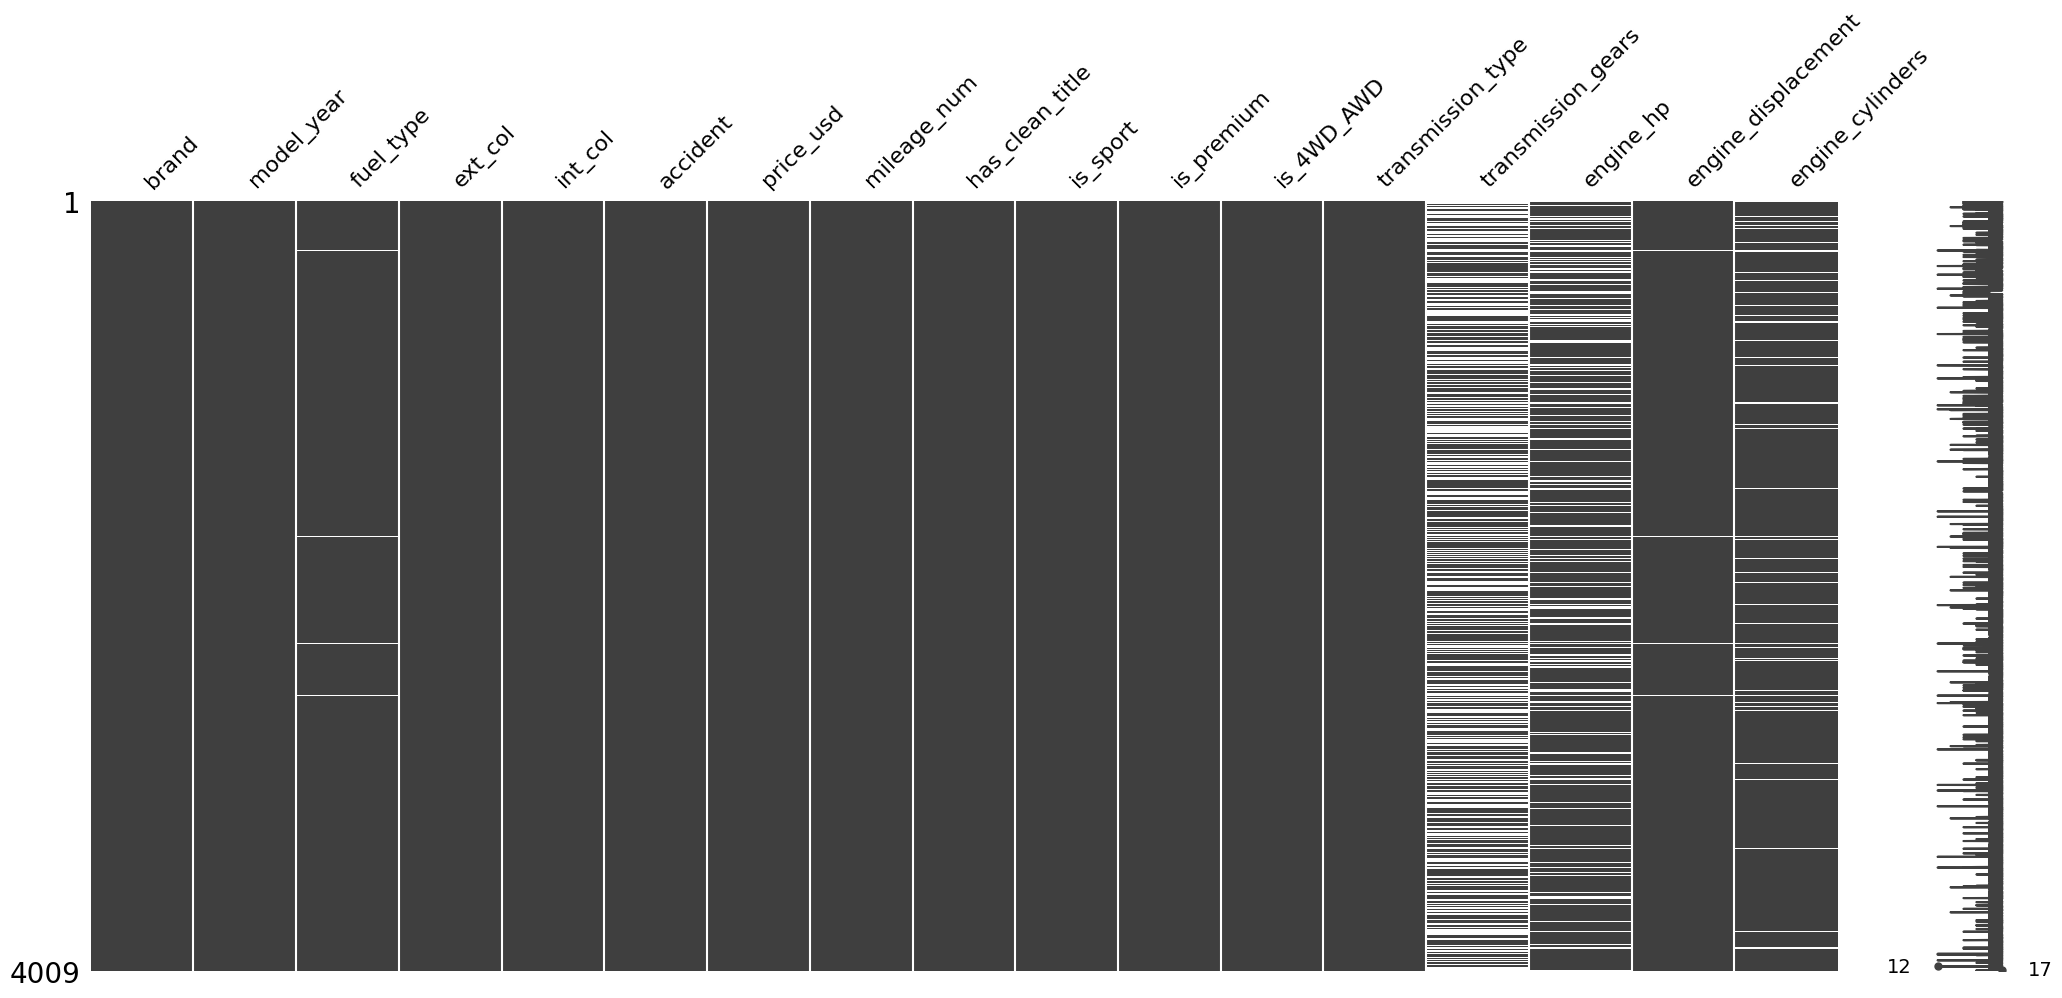

In [ ]:
import missingno as msno
import matplotlib.pyplot as plt

# Visualizes the dataset as a matrix where white lines represent missing values
msno.matrix(df)
plt.show()

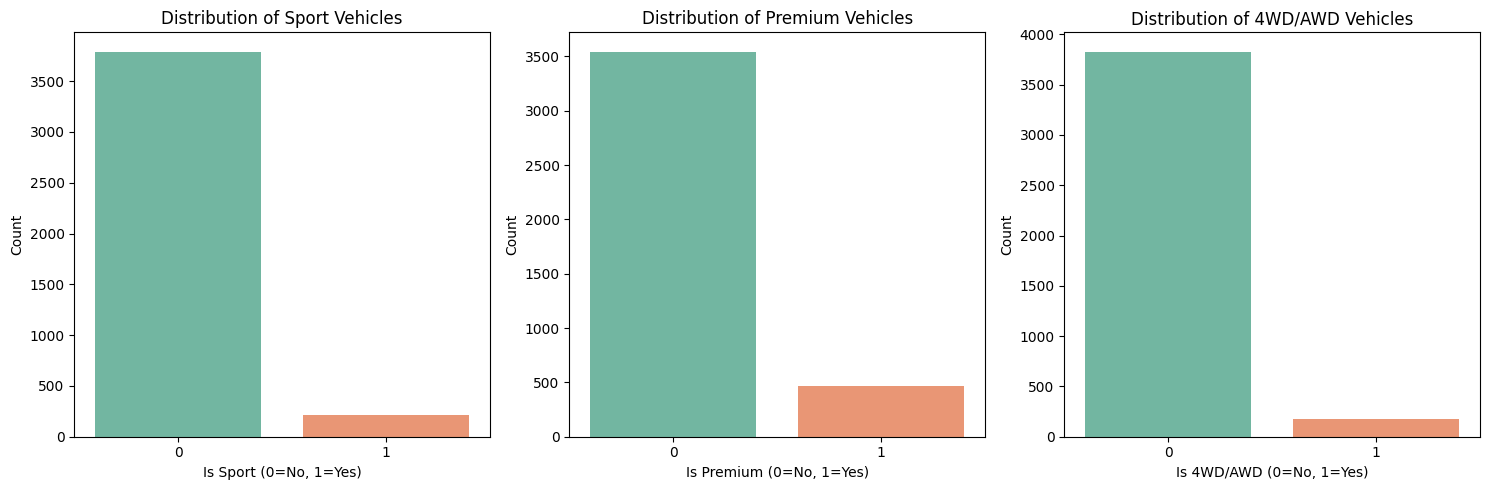

In [ ]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 5))

# Plot is_sport
sns.countplot(data=df, x='is_sport', ax=axes[0], palette='Set2')
axes[0].set_title('Distribution of Sport Vehicles')
axes[0].set_xlabel('Is Sport (0=No, 1=Yes)')
axes[0].set_ylabel('Count')

# Plot is_premium
sns.countplot(data=df, x='is_premium', ax=axes[1], palette='Set2')
axes[1].set_title('Distribution of Premium Vehicles')
axes[1].set_xlabel('Is Premium (0=No, 1=Yes)')
axes[1].set_ylabel('Count')

# Plot is_4WD_AWD
sns.countplot(data=df, x='is_4WD_AWD', ax=axes[2], palette='Set2')
axes[2].set_title('Distribution of 4WD/AWD Vehicles')
axes[2].set_xlabel('Is 4WD/AWD (0=No, 1=Yes)')
axes[2].set_ylabel('Count')

plt.tight_layout()
plt.show()      

<Axes: xlabel='transmission_type'>

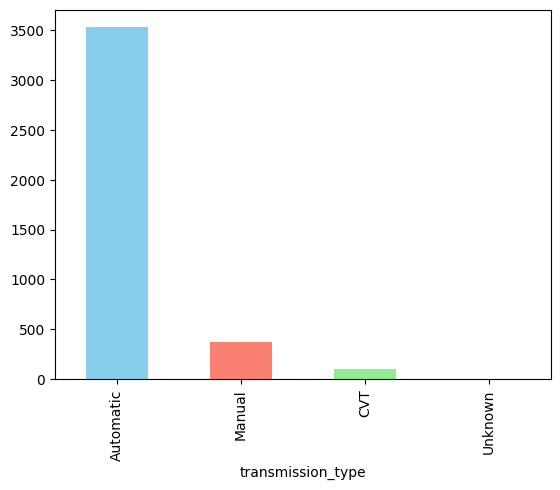

In [ ]:
df['transmission_type'].value_counts().plot(kind='bar', color=['skyblue', 'salmon', 'lightgreen', 'gray'])

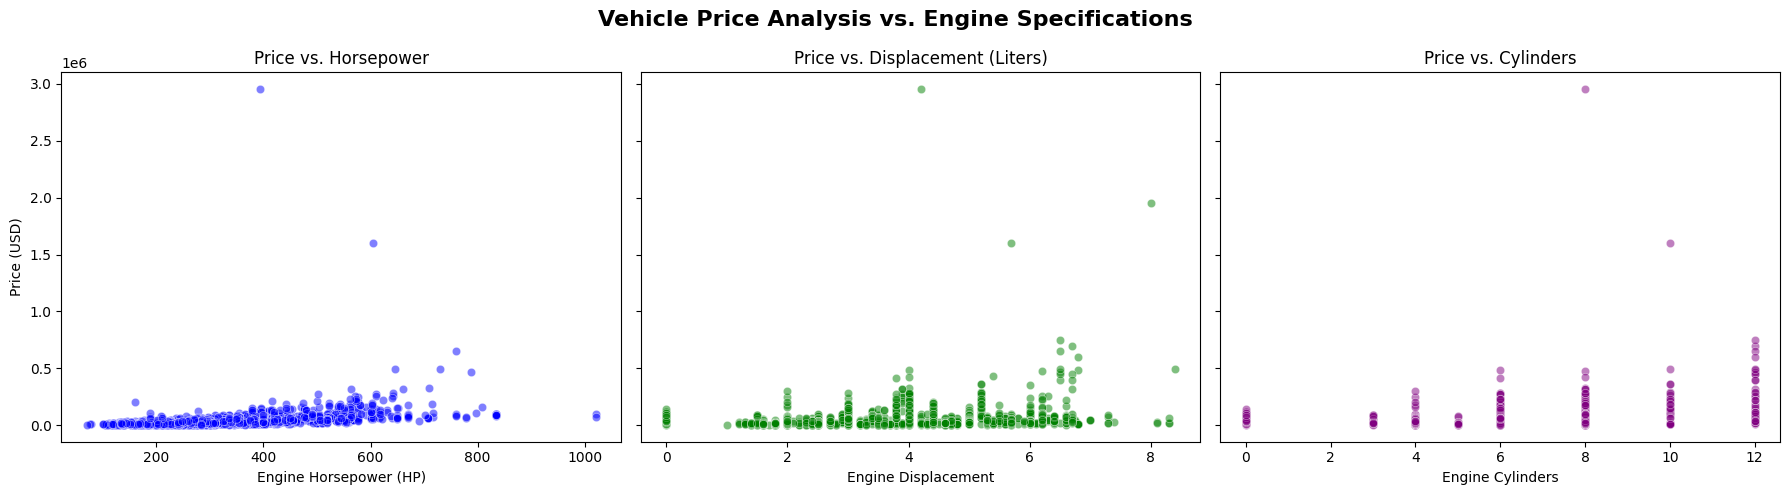

In [ ]:

# Set up a 1x3 grid of subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
fig.suptitle('Vehicle Price Analysis vs. Engine Specifications', fontsize=16, fontweight='bold')

# Subplot 1: Price vs. Engine Horsepower
sns.scatterplot(data=df, x='engine_hp', y='price_usd', alpha=0.5, ax=axes[0], color='blue')
axes[0].set_title('Price vs. Horsepower')
axes[0].set_xlabel('Engine Horsepower (HP)')
axes[0].set_ylabel('Price (USD)')

# Subplot 2: Price vs. Engine Displacement
sns.scatterplot(data=df, x='engine_displacement', y='price_usd', alpha=0.5, ax=axes[1], color='green')
axes[1].set_title('Price vs. Displacement (Liters)')
axes[1].set_xlabel('Engine Displacement')

# Subplot 3: Price vs. Engine Cylinders
# Using a scatterplot with jitter or a boxplot often works best for discrete counts like cylinders
sns.scatterplot(data=df, x='engine_cylinders', y='price_usd', alpha=0.5, ax=axes[2], color='purple')
axes[2].set_title('Price vs. Cylinders')
axes[2].set_xlabel('Engine Cylinders')

# Clean up spacing and display
plt.tight_layout()
plt.show()

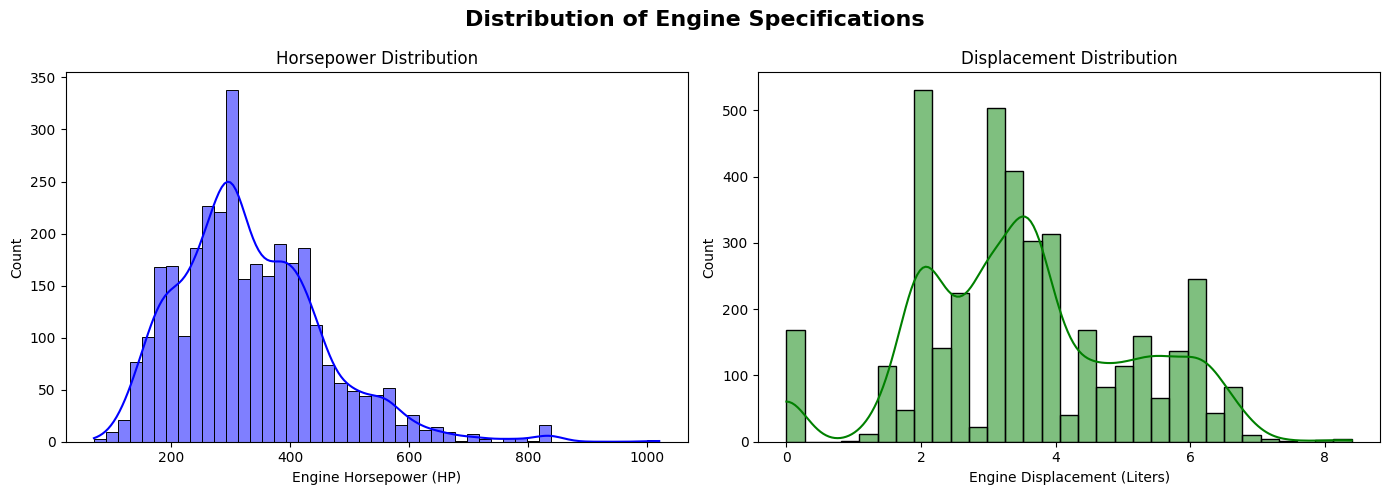

In [ ]:
# Select the two columns to visualize
cols_to_plot = ['engine_hp', 'engine_displacement']

# Set up a clean 1x2 grid of subplots (changed from 1, 3 to 1, 2)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribution of Engine Specifications', fontsize=16, fontweight='bold')

# Subplot 1: Distribution of Horsepower
sns.histplot(data=df, x='engine_hp', ax=axes[0], color='blue', kde=True)
axes[0].set_title('Horsepower Distribution')
axes[0].set_xlabel('Engine Horsepower (HP)')
axes[0].set_ylabel('Count')

# Subplot 2: Distribution of Engine Displacement
sns.histplot(data=df, x='engine_displacement', ax=axes[1], color='green', kde=True)
axes[1].set_title('Displacement Distribution')
axes[1].set_xlabel('Engine Displacement (Liters)')
axes[1].set_ylabel('Count')

# Clean up spacing and display
plt.tight_layout()
plt.show()

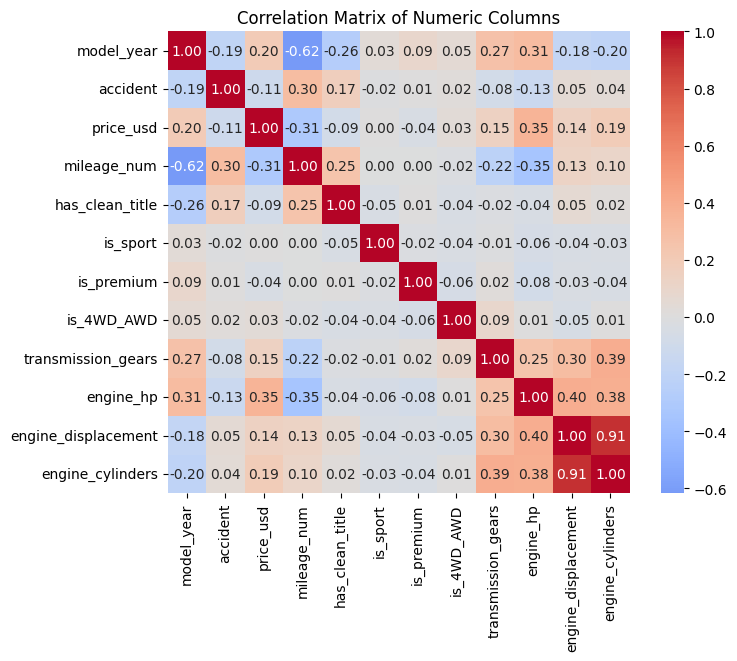

In [ ]:
numeric_cols = df.select_dtypes(include=np.number).columns
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Correlation Matrix of Numeric Columns')
plt.show()

### Handle missing values

In [ ]:
## Remove engine cylinders as it is correlated with engine _displacement
df.drop(['engine_cylinders', 'transmission_gears'], axis=1, inplace=True)


In [ ]:
# Fill missing HP with the median horsepower of its specific car brand
df['engine_hp'] = df.groupby('brand')['engine_hp'].transform(lambda x: x.fillna(x.median()))

# Fallback: If a brand is entirely missing HP data, fill with the overall global median
df['engine_hp'] = df['engine_hp'].fillna(df['engine_hp'].median())


In [ ]:
pd.qcut(df["engine_hp"], q=15, labels=False, duplicates="drop")

0        5
1        2
2        6
3        9
4        8
        ..
4004    14
4005     8
4006    10
4007    13
4008     3
Name: engine_hp, Length: 4009, dtype: int64

In [ ]:
df['brand'].value_counts().index

Index(['Ford', 'BMW', 'Mercedes-Benz', 'Chevrolet', 'Porsche', 'Audi',
       'Toyota', 'Lexus', 'Jeep', 'Land', 'Nissan', 'Cadillac', 'GMC', 'RAM',
       'Dodge', 'Tesla', 'Kia', 'Hyundai', 'Acura', 'Subaru', 'Mazda', 'Honda',
       'INFINITI', 'Volkswagen', 'Lincoln', 'Jaguar', 'Volvo', 'Maserati',
       'Bentley', 'MINI', 'Buick', 'Chrysler', 'Lamborghini', 'Genesis',
       'Mitsubishi', 'Alfa', 'Rivian', 'Hummer', 'Pontiac', 'Ferrari',
       'Rolls-Royce', 'Aston', 'Scion', 'McLaren', 'Saturn', 'FIAT', 'Lotus',
       'Lucid', 'Mercury', 'Karma', 'Saab', 'Bugatti', 'Polestar', 'Plymouth',
       'smart', 'Maybach', 'Suzuki'],
      dtype='str', name='brand')

In [ ]:
df.shape

(4009, 15)

In [ ]:
df['fuel_type'].value_counts()

fuel_type
Gasoline          3309
Hybrid             194
Electric           167
E85 Flex Fuel      139
Diesel             116
Plug-In Hybrid      34
Name: count, dtype: int64

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4009 entries, 0 to 4008
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   brand                4009 non-null   str    
 1   model_year           4009 non-null   int64  
 2   fuel_type            3959 non-null   str    
 3   ext_col              4009 non-null   str    
 4   int_col              4009 non-null   str    
 5   accident             4009 non-null   float64
 6   price_usd            4009 non-null   int64  
 7   mileage_num          4009 non-null   int64  
 8   has_clean_title      4009 non-null   int64  
 9   is_sport             4009 non-null   int64  
 10  is_premium           4009 non-null   int64  
 11  is_4WD_AWD           4009 non-null   int64  
 12  transmission_type    4009 non-null   str    
 13  engine_hp            4009 non-null   float64
 14  engine_displacement  3953 non-null   float64
dtypes: float64(3), int64(7), str(5)
memory usage: 469

In [ ]:

### For displacemnt
def rescue_missing_rows_vectorized(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # 1. Clean the string columns to ensure NaNs are true NaNs
    df['fuel_type'] = df['fuel_type']

    # 2. Step 1: Explicitly handle the true Electric Vehicles (Teslas, etc.)
    ev_brands = ["tesla", "rivian", "lucid", "polestar"]
    is_ev = df["brand"].astype(str).str.lower().str.strip().isin(ev_brands)
    
    df.loc[is_ev & df["engine_displacement"].isna(), "engine_displacement"] = 0.0
    df.loc[is_ev & df["fuel_type"].isna(), "fuel_type"] = "Electric"

    # 3. Step 2: Rescue the combustion cars using Horsepower Neighbors!
    # Find vehicles of the same brand with similar horsepower to borrow their median displacement
    brand_hp_map = df.groupby(["brand", "engine_hp"])["engine_displacement"].transform("median")
    df["engine_displacement"] = df["engine_displacement"].fillna(brand_hp_map)

    # Global fallback for displacement if it's a completely unique standalone horsepower
    df["engine_displacement"] = df["engine_displacement"].fillna(df["engine_displacement"].median())

    # 4. Step 3: Fill the missing fuel types with the brand's most common fuel type (usually Gasoline)
    brand_fuel_mode = df.groupby("brand")["fuel_type"].transform(
        lambda x: x.fillna(x.mode()[0] if not x.mode().empty else "Gasoline")
    )
    df["fuel_type"] = df["fuel_type"].fillna(brand_fuel_mode)

    return df

# --- Run the pipeline ---
df = rescue_missing_rows_vectorized(df)

In [ ]:
import numpy as np
import pandas as pd


def rescue_displacement_via_hp_bins(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # Step 1: Handle True Electric Vehicles First (They must structurally be 0.0L)
    ev_brands = ["tesla", "rivian", "lucid", "polestar"]
    is_ev_brand = df["brand"].astype(str).str.lower().str.strip().isin(ev_brands)
    df.loc[is_ev_brand & df["engine_displacement"].isna(), "engine_displacement"] = 0.0

    # ------------------------------------------------------------------
    # Step 2: YOUR STRATEGY - Discretize Horsepower into 15 Quantile Bins
    # ------------------------------------------------------------------
    # Using pd.qcut ensures that each of the 15 bins has an equal number of cars,
    # optimizing statistical density. 'duplicates="drop"' handles tight clusters.
    if "engine_hp" in df.columns and df["engine_hp"].notna().any():
        df["hp_bin"] = pd.qcut(df["engine_hp"], q=15, labels=False, duplicates="drop")

        # Tier 1: Group by BRAND and HORSEPOWER BIN (Your idea + Localized Brand anchor)
        # This fixes a 285 HP Chrysler using other mid-power Chryslers.
        brand_hp_bin_map = df.groupby(["brand", "hp_bin"])["engine_displacement"].transform("median")
        df["engine_displacement"] = df["engine_displacement"].fillna(brand_hp_bin_map)

        # Tier 2: Group by HORSEPOWER BIN Globally (Purely your fallback strategy)
        # If a brand has no matching power tier rows, use the industry baseline for that power range.
        global_hp_bin_map = df.groupby("hp_bin")["engine_displacement"].transform("median")
        df["engine_displacement"] = df["engine_displacement"].fillna(global_hp_bin_map)

        # Clean up the working bucket column
        df = df.drop(columns=["hp_bin"])


    # Tier 3: Ultimate Global Dataset Fallback
    global_median = df["engine_displacement"].median()
    df["engine_displacement"] = df["engine_displacement"].fillna(global_median)

    return df


# --- Execution ---
df = rescue_displacement_via_hp_bins(df)

In [ ]:
df

,brand,model_year,fuel_type,ext_col,int_col,accident,price_usd,mileage_num,has_clean_title,is_sport,is_premium,is_4WD_AWD,transmission_type,engine_hp,engine_displacement
0,Ford,2013,E85 Flex Fuel,Black,Black,1.0,10300,51000,1,0,0,0,Automatic,300.0,3.7
1,Hyundai,2021,Gasoline,White,Gray,1.0,38005,34742,1,0,0,0,Automatic,240.0,3.8
2,Lexus,2022,Gasoline,Blue,Black,0.0,54598,22372,0,0,0,0,Automatic,301.0,3.5
3,INFINITI,2015,Hybrid,Black,Black,0.0,15500,88900,1,1,0,0,Automatic,354.0,3.5
4,Audi,2021,Gasoline,White,Black,0.0,34999,9835,0,0,1,0,Automatic,333.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4004,Bentley,2023,Gasoline,Other,Red,0.0,349950,714,1,0,0,0,Automatic,552.0,6.0
4005,Audi,2022,Gasoline,Black,Black,0.0,53900,10900,1,0,1,0,Automatic,349.0,3.0
4006,Porsche,2022,Electric,Black,Black,0.0,90998,2116,0,0,0,0,Automatic,365.0,0.0
4007,Ford,2020,Gasoline,Blue,Black,0.0,62999,33000,1,0,0,0,Automatic,450.0,3.5


In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4009 entries, 0 to 4008
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   brand                4009 non-null   str    
 1   model_year           4009 non-null   int64  
 2   fuel_type            4009 non-null   str    
 3   ext_col              4009 non-null   str    
 4   int_col              4009 non-null   str    
 5   accident             4009 non-null   float64
 6   price_usd            4009 non-null   int64  
 7   mileage_num          4009 non-null   int64  
 8   has_clean_title      4009 non-null   int64  
 9   is_sport             4009 non-null   int64  
 10  is_premium           4009 non-null   int64  
 11  is_4WD_AWD           4009 non-null   int64  
 12  transmission_type    4009 non-null   str    
 13  engine_hp            4009 non-null   float64
 14  engine_displacement  4009 non-null   float64
dtypes: float64(3), int64(7), str(5)
memory usage: 469

In [ ]:
df

,brand,model_year,fuel_type,ext_col,int_col,accident,price_usd,mileage_num,has_clean_title,is_sport,is_premium,is_4WD_AWD,transmission_type,engine_hp,engine_displacement
0,Ford,2013,E85 Flex Fuel,Black,Black,1.0,10300,51000,1,0,0,0,Automatic,300.0,3.7
1,Hyundai,2021,Gasoline,White,Gray,1.0,38005,34742,1,0,0,0,Automatic,240.0,3.8
2,Lexus,2022,Gasoline,Blue,Black,0.0,54598,22372,0,0,0,0,Automatic,301.0,3.5
3,INFINITI,2015,Hybrid,Black,Black,0.0,15500,88900,1,1,0,0,Automatic,354.0,3.5
4,Audi,2021,Gasoline,White,Black,0.0,34999,9835,0,0,1,0,Automatic,333.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4004,Bentley,2023,Gasoline,Other,Red,0.0,349950,714,1,0,0,0,Automatic,552.0,6.0
4005,Audi,2022,Gasoline,Black,Black,0.0,53900,10900,1,0,1,0,Automatic,349.0,3.0
4006,Porsche,2022,Electric,Black,Black,0.0,90998,2116,0,0,0,0,Automatic,365.0,0.0
4007,Ford,2020,Gasoline,Blue,Black,0.0,62999,33000,1,0,0,0,Automatic,450.0,3.5


In [ ]:
df['brand'].nunique()

57

In [ ]:
df.nunique()

brand                    57
model_year               34
fuel_type                 6
ext_col                   9
int_col                   9
accident                  2
price_usd              1569
mileage_num            2818
has_clean_title           2
is_sport                  2
is_premium                2
is_4WD_AWD                2
transmission_type         4
engine_hp               349
engine_displacement      61
dtype: int64

### Now let's do encoding

In [ ]:

from sklearn.preprocessing import OneHotEncoder
def one_hot_encode_selected(df: pd.DataFrame):
    df = df.copy()

    categorical_features = ["fuel_type", "transmission_type" , "int_col", "ext_col" ]

    encoder = OneHotEncoder(
        drop="first",
        handle_unknown="ignore",
        sparse_output=False
    )

    encoded_array = encoder.fit_transform(df[categorical_features])

    encoded_df = pd.DataFrame(
        encoded_array,
        columns=encoder.get_feature_names_out(categorical_features),
        index=df.index
    )

    df = df.drop(columns=categorical_features)
    df = pd.concat([df, encoded_df], axis=1)

    return df

In [ ]:
df = one_hot_encode_selected(df)

In [ ]:
from category_encoders import TargetEncoder
from sklearn.model_selection import KFold

# --- Assumption Check ---
# X_train is your DataFrame containing features (including 'brand')
# y_train is your Series containing 'price_usd'

# 1. Initialize a blank column in a copy of your data to store encoded values
X_train_encoded = df.copy()
X_train_encoded["brand"] = np.nan

# 2. Set up the 5-Fold split strategy
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# 3. Loop through the folds manually to calculate out-of-fold values cleanly
for train_idx, val_idx in kf.split(df):
    # Split training into 4 chunks (fit) and 1 chunk (transform)
    X_tr, X_val = df.iloc[train_idx], df.iloc[val_idx]
    y_tr = df.iloc[train_idx]['price_usd']

    # Initialize a baseline encoder for this specific fold chunk
    # (Notice we dropped 'cv' from here so it works flawlessly on any version)
    fold_encoder = TargetEncoder(cols=["brand"], smoothing=10.0)

    # Fit on the 4 chunks, transform the 1 remaining validation chunk
    fold_encoder.fit(X_tr, y_tr)
    X_train_encoded.iloc[val_idx, X_train_encoded.columns.get_loc("brand")] = (
        fold_encoder.transform(X_val)["brand"]
    )

# 4. Final step: Create a master encoder fit on ALL of X_train
# We need this to transform your future X_test set when evaluating your model!



### D'Agostino's $K^2$ Normality test

In [ ]:
df = X_train_encoded

In [ ]:
import scipy.stats as stats


def statistical_normality_test(df, column_name, alpha=0.05):
    # Strip missing values as tests cannot handle NaNs
    data_clean = df[column_name].dropna()
    
    # Calculate D'Agostino's K^2 Test
    stat, p_value = stats.normaltest(data_clean)
    
    
    # Interpret the P-Value
    if p_value > alpha:
        print(f"{col}, looks normal with p-value {p_value}")
    else:
         print(f"{col}, doesn't looks normal with p-value {p_value}")
   

# --- How to run ---
# stat, p = statistical_normality_test(X_train, 'engine_hp')

In [ ]:
df

,brand,model_year,accident,price_usd,mileage_num,has_clean_title,is_sport,is_premium,is_4WD_AWD,engine_hp,engine_displacement,fuel_type_E85 Flex Fuel,fuel_type_Electric,fuel_type_Gasoline,fuel_type_Hybrid,fuel_type_Plug-In Hybrid,transmission_type_CVT,transmission_type_Manual,transmission_type_Unknown,int_col_Black,int_col_Blue,int_col_Brown,int_col_Gray,int_col_Orange,int_col_Other,int_col_Red,int_col_White,ext_col_Black,ext_col_Blue,ext_col_Brown,ext_col_Gray,ext_col_Orange,ext_col_Other,ext_col_Red,ext_col_White
0,36071.804636,2013,1.0,10300,51000,1,0,0,0,300.0,3.7,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,19266.183557,2021,1.0,38005,34742,1,0,0,0,240.0,3.8,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,37364.900874,2022,0.0,54598,22372,0,0,0,0,301.0,3.5,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
3,23646.368802,2015,0.0,15500,88900,1,1,0,0,354.0,3.5,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,39621.337648,2021,0.0,34999,9835,0,0,1,0,333.0,2.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4004,98064.013592,2023,0.0,349950,714,1,0,0,0,552.0,6.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4005,39814.217964,2022,0.0,53900,10900,1,0,1,0,349.0,3.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4006,85310.780675,2022,0.0,90998,2116,0,0,0,0,365.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4007,34763.596774,2020,0.0,62999,33000,1,0,0,0,450.0,3.5,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
numeric_cols = ['engine_displacement', 'engine_hp', 'mileage_num', 'price_usd']
for col in numeric_cols:
    statistical_normality_test(df, col)

engine_displacement, doesn't looks normal with p-value 0.00021523436870315069
engine_hp, doesn't looks normal with p-value 2.6137116591576264e-144
mileage_num, doesn't looks normal with p-value 2.5092146060804757e-164
price_usd, doesn't looks normal with p-value 0.0


In [ ]:
def check_outlier_qa(df, numeric_cols):
    # Select only numeric columns

    print("--- Outlier Detection Report (IQR Method) ---")

    for col in numeric_cols:
        # Calculate quartiles
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3 - q1

        # Define bounds
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr

        # Count outliers
        outliers = df[
            (df[col] < lower_bound)
            | (df[col] > upper_bound)
        ]
        num_outliers = len(outliers)
        total_rows = len(df)
        percentage = (num_outliers / total_rows) * 100

        # Print results for the column
        print(
            f"Column '{col}': {num_outliers} outliers found ({percentage:.2f}% of data)"
        )

In [ ]:
df.shape

(4009, 35)

In [ ]:
check_outlier_qa(df = df, numeric_cols=numeric_cols)

--- Outlier Detection Report (IQR Method) ---
Column 'engine_displacement': 7 outliers found (0.17% of data)
Column 'engine_hp': 102 outliers found (2.54% of data)
Column 'mileage_num': 69 outliers found (1.72% of data)
Column 'price_usd': 244 outliers found (6.09% of data)


In [ ]:
df['price_usd'] = np.log1p(df['price_usd']).values
df['mileage_num'] = np.log1p(df['mileage_num']).values

In [ ]:
df

,brand,model_year,accident,price_usd,mileage_num,has_clean_title,is_sport,is_premium,is_4WD_AWD,engine_hp,engine_displacement,fuel_type_E85 Flex Fuel,fuel_type_Electric,fuel_type_Gasoline,fuel_type_Hybrid,fuel_type_Plug-In Hybrid,transmission_type_CVT,transmission_type_Manual,transmission_type_Unknown,int_col_Black,int_col_Blue,int_col_Brown,int_col_Gray,int_col_Orange,int_col_Other,int_col_Red,int_col_White,ext_col_Black,ext_col_Blue,ext_col_Brown,ext_col_Gray,ext_col_Orange,ext_col_Other,ext_col_Red,ext_col_White
0,36071.804636,2013,1.0,9.239996,10.839601,1,0,0,0,300.0,3.7,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,19266.183557,2021,1.0,10.545499,10.455733,1,0,0,0,240.0,3.8,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,37364.900874,2022,0.0,10.907771,10.015610,0,0,0,0,301.0,3.5,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
3,23646.368802,2015,0.0,9.648660,11.395279,1,1,0,0,354.0,3.5,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,39621.337648,2021,0.0,10.463103,9.193804,0,0,1,0,333.0,2.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4004,98064.013592,2023,0.0,12.765548,6.572283,1,0,0,0,552.0,6.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4005,39814.217964,2022,0.0,10.894904,9.296610,1,0,1,0,349.0,3.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4006,85310.780675,2022,0.0,11.418604,7.657755,0,0,0,0,365.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4007,34763.596774,2020,0.0,11.050890,10.404293,1,0,0,0,450.0,3.5,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
from sklearn.model_selection import train_test_split

X_train = df.drop(columns=['price_usd'])
y_train = df['price_usd']
X_train, X_test, y_train, y_test = train_test_split(X_train, y_train, test_size=0.2, random_state=42)


In [1]:
import pandas as pd

In [4]:
pd.read_csv('../test.csv')

,Unnamed: 0,brand,model_year,accident,price_usd,mileage_num,has_clean_title,is_sport,is_premium,is_4WD_AWD,...,int_col_White,int_col_nan,ext_col_Black,ext_col_Blue,ext_col_Brown,ext_col_Gray,ext_col_Orange,ext_col_Red,ext_col_White,ext_col_nan
0,0,9.911786,2022,0.0,10.389026,9.259226,1,0,1,0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1,1,10.261014,2016,0.0,9.998616,10.590390,1,0,0,0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2,10.127484,2020,0.0,10.110136,10.576253,0,0,1,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,3,10.251273,2015,0.0,10.043249,11.869151,1,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,4,9.726482,2021,0.0,10.232755,9.974831,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
998,998,9.979454,2021,1.0,10.655917,10.347596,1,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
999,999,10.047213,2010,0.0,10.199919,11.400887,1,0,1,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1000,1000,10.273095,2021,0.0,10.659398,11.039042,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1001,1001,9.965305,2003,1.0,9.278092,11.643962,1,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
